# Controlling an interferometer using EPICS and a stage using ophyd
awojdyla@lbl.gov, Feb 2026

In [ ]:
#!pip install pyepics
# !pip install ophyd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 31.1 MB/s  0:00:00m0:00:01


In [1]:
#using base 3.13.5 on GW
import epics
import ophyd

## Reading the PV for the interferometer
We assume that an IOC is running for the Smaract interferomter, and that we can poll it through the network

In [2]:
epics.caget('CATERETE:PICOSCALE:POS_0')

-786381445

## Moving the stage

### using the python package

In [4]:
#!pip install newportxps

### create an ophyd wrapper

In [3]:
from ophyd import Device, Component as Cpt, Signal
from ophyd import EpicsSignal
from ophyd.status import SubscriptionStatus
import threading
import time

class NewportXPSMotor(Device):
    # Ophyd signals
    user_readback = Cpt(Signal, value=0, kind='hinted')
    user_setpoint = Cpt(Signal, value=0, kind='normal')
    
    def __init__(self, ip_address, stage_name, username='Administrator', 
                 password='Administrator', *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        from newportxps import NewportXPS
        
        self.stage_name = stage_name
        self.group_name = stage_name.split('.')[0]  # Extract 'Group1' from 'Group1.Pos'
        self.xps = NewportXPS(ip_address, username=username, password=password)
        
        # Update initial position
        self._update_position()
        
    def _update_position(self):
        """Read current position from hardware"""
        pos = self.xps.read_stage_position(self.stage_name)
        self.user_readback.put(pos)
        return pos
    
    def _is_moving(self):
        """Check if the motor is currently moving"""
        status = self.xps.get_group_status()
        group_status = status.get(self.group_name, '')
        return 'Moving' in group_status
    
    def set(self, position, timeout=30):
        """Move to a position and return a status object"""
        
        def check_done(*, old_value, value, **kwargs):
            """Callback to check if motion is complete"""
            return not self._is_moving()
        
        # Start the move
        self.user_setpoint.put(position)
        self.xps.move_stage(self.stage_name, position)
        
        # Create a status object that monitors completion
        status = SubscriptionStatus(self.user_readback, check_done, timeout=timeout)
        
        # Start a background thread to update position during motion
        def monitor_motion():
            while not status.done:
                self._update_position()
                time.sleep(0.05)  # 50ms polling
            # Final position update
            self._update_position()
        
        thread = threading.Thread(target=monitor_motion, daemon=True)
        thread.start()
        
        return status
    
    def read(self):
        """Read current position"""
        pos = self._update_position()
        return {f'{self.name}_user_readback': {'value': pos, 'timestamp': time.time()}}
    
    def describe(self):
        """Describe the readback signal"""
        return {f'{self.name}_user_readback': {
            'source': f'XPS:{self.stage_name}',
            'dtype': 'number',
            'shape': []
        }}

In [8]:
#!pip install newportxps

In [4]:
#stock ophyd opbject for EPICS signal
interf = EpicsSignal('CATERETE:PICOSCALE:POS_0', name='interferometer_position')

#custom ophyd object
motor = NewportXPSMotor(
    ip_address='192.168.10.20',
    stage_name='Group1.Pos',
    username='Administrator',
    password='Administrator',
    name='xps_motor'
)

pos_inter_m = interf.get()*1e-12
pos_readback_m = motor.get()[0]*1e-3
print(f"Interferometer position: {pos_inter_m*1e3} mm")
print(f"Motor readback position: {pos_readback_m*1e3} mm")


Interferometer position: -0.786324274 mm
Motor readback position: 10.000004000000002 mm


In [7]:
from tiled.client import from_uri
import os
from bluesky import plans as bp
from bluesky.callbacks.tiled_writer import TiledWriter

#import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
#api_key_filepath = "C:\\Users\\admin\\Documents\\TILED_SINGLE_USER_API_KEY.txt"
#with open(api_key_filepath, 'r') as f:
#    api_key = f.read().strip()
#os.environ["TILED_SINGLE_USER_API_KEY"] = api_key

if not api_key:
   raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")
#from bluesky.callbacks.tiled_writer import TiledWriter

tiled_client = from_uri("http://localhost:8000/", api_key=api_key)
tw = TiledWriter(tiled_client)

from bluesky import RunEngine
RE = RunEngine()
RE.subscribe(tw)
from bluesky.callbacks.best_effort import BestEffortCallback
bec = BestEffortCallback()

# Send all metadata/data captured to the BestEffortCallback.
RE.subscribe(bec)

#RE(bp.scan([interf, motor], motor, -10, 10, 11))
#RE(bp.count([interf], 11))

1



Transient Scan ID: 1     Time: 2026-03-16 13:07:43
Persistent Unique Scan ID: '93521de9-7bd1-42a8-b310-1f24ac4064cb'
New stream: 'primary'
+-----------+------------+-------------------------+
|   seq_num |       time | interferometer_position |
+-----------+------------+-------------------------+
|         1 | 13:07:43.7 |              -786403957 |
|         2 | 13:07:43.8 |              -786422092 |
|         3 | 13:07:43.8 |              -786418960 |
|         4 | 13:07:43.9 |              -786414631 |
|         5 | 13:07:43.9 |              -786399035 |
|         6 | 13:07:44.0 |              -786406474 |
|         7 | 13:07:44.0 |              -786414981 |
|         8 | 13:07:44.0 |              -786399984 |
|         9 | 13:07:44.1 |              -786406486 |
|        10 | 13:07:44.1 |              -786394059 |
|        11 | 13:07:44.2 |              -786407358 |
+-----------+------------+-------------------------+
generator count ['93521de9'] (scan num: 1)





('93521de9-7bd1-42a8-b310-1f24ac4064cb',)

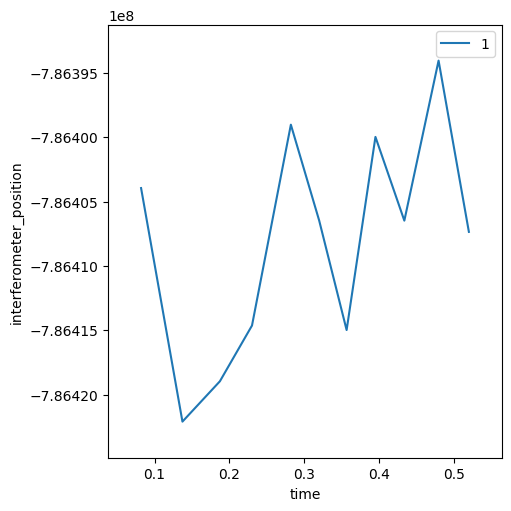

In [8]:
RE(bp.count([interf], 11))



Transient Scan ID: 2     Time: 2026-03-16 13:08:26
Persistent Unique Scan ID: 'caaa9906-0036-4983-a294-7496bf92f6ca'
New stream: 'primary'
+-----------+------------+-------------------------+-------------------------+
|   seq_num |       time | xps_motor_user_readback | interferometer_position |
+-----------+------------+-------------------------+-------------------------+
|         1 | 13:08:27.1 |                 -10.000 |               688442393 |
|         2 | 13:08:27.3 |                  -8.000 |             -1781304191 |
|         3 | 13:08:27.4 |                  -6.000 |               393573137 |
|         4 | 13:08:27.6 |                  -4.000 |             -1911613701 |
|         5 | 13:08:27.8 |                  -2.000 |                 8938337 |
|         6 | 13:08:27.9 |                   0.000 |              1938962432 |
|         7 | 13:08:28.1 |                   2.000 |              -196656647 |
|         8 | 13:08:28.3 |                   4.000 |              177

('caaa9906-0036-4983-a294-7496bf92f6ca',)

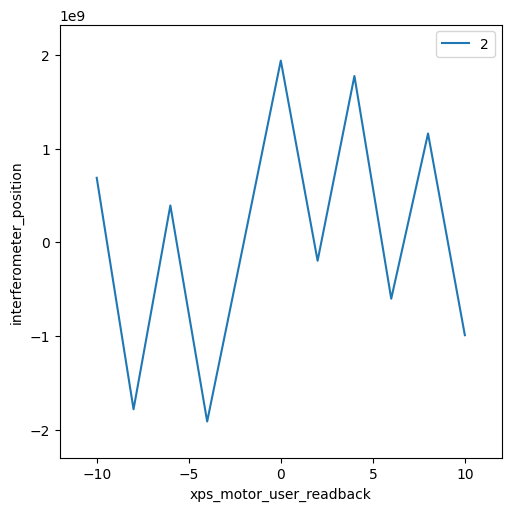

In [9]:
RE(bp.scan([interf, motor], motor, -10, 10, 11))

In [ ]:
from tiled.client import simple
c = simple('../data/test')  # or just simple() for temporary/dev storage
#ifndef 
# c.create_container('raw', specs=['CatalogOfBlueskyRuns'])

from bluesky.callbacks.tiled_writer import TiledWriter
tw = TiledWriter(c['raw'])

from bluesky import RunEngine
RE = RunEngine()
RE.subscribe(tw)

RE(bp.scan([interf, motor], motor, -10, 10, 11))

Tiled version 0.2.6


http://127.0.0.1:36915/api/v1?api_key=d4570af0de030703


('be1ec374-968d-4f82-ad7d-2bb965085efd',)

In [20]:
db = c['be1ec374-968d-4f82-ad7d-2bb965085efd']




KeyError: 'be1ec374-968d-4f82-ad7d-2bb965085efd'

In [25]:
from bluesky.callbacks.tiled_writer import TiledWriter
#from envs.p312.Lib import http
from tiled.client import from_uri

# Connect to your local server
#tiled_client = from_uri("http://127.0.0.1:8000?api_key=b762dd7884cae5dd192841af420db11edc3dc16001b7b6c948945e82c0075596") 
#tiled_client = from_uri('http://192.168.10.240:8000?api_key=e73d7fa0c47f4b9f1a230526e1d3d669d6dcdd06ce96ab0391a00f431347de69')

tiled_client = from_uri('http://192.168.10.240:8000?api_key=AAA')

# from bluesky.callbacks.tiled_writer import TiledWriter
# tiled_writer = TiledWriter(tiled_server)

# Initialize and subscribe
tw = TiledWriter(tiled_client)
RE.subscribe(tw)

RE(bp.scan([interf, motor], motor, -10.0, 10.0, 11))

/home/psduser/miniconda3/lib/python3.13/site-packages/event_model/__init__.py:211: UserWarning: The callback <bluesky.callbacks.tiled_writer.RunNormalizer object at 0x7e9d5a3df9b0> raised ClientError('409: /69f90b16-bfe0-475c-9ae4-a9f190cc3b79 http://192.168.10.240:8000/api/v1/metadata/') when RunRouter passed it a 'start' document. This is probably because in earlier releases the RunRouter expected its factory functions to forward the 'start' document, but starting in event-model 1.14.0 the RunRouter passes in the document, causing the callback to receive it twice and potentially raise an error. Update the factory function. In a future release this warning will become an error.
  output_doc = getattr(self, name)(doc)
Run aborted
Traceback (most recent call last):
  File "/home/psduser/miniconda3/lib/python3.13/site-packages/tiled/client/utils.py", line 74, in handle_error
    raise_for_status(response)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "/home/psduser/miniconda3/lib/python3.13/site

ClientError: 409: /69f90b16-bfe0-475c-9ae4-a9f190cc3b79 http://192.168.10.240:8000/api/v1/metadata/

## using ALS bl 5.3.1 tiled server